# Model 01: Prophet Baseline

Facebook Prophet serves as our baseline model. It's good for:
- Capturing seasonality (weekly, yearly)
- Handling holidays
- Identifying trend changepoints
- Adding external regressors (mobility, weather)

**Note:** If Prophet is not installed, run: `pip install prophet`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import subprocess

# Check and install prophet if needed
try:
    from prophet import Prophet
except ImportError:
    print("Prophet not installed. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "prophet", "--quiet"])
    print("✓ Prophet installed successfully!")

sys.path.insert(0, '..')

from src.models.prophet_model import ProphetModel
from src.evaluation.metrics import MetricsCalculator, train_test_split_by_date

# Load data
df = pd.read_csv('../data/processed/features_full.csv', parse_dates=['date'])
print(f"Data loaded: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Prophet not installed. Installing...
✓ Prophet installed successfully!
Data loaded: (1143, 53)
Date range: 2020-01-22 00:00:00 to 2023-03-09 00:00:00


## Train-Test Split

In [3]:
# Time-based split
train_df, val_df, test_df = train_test_split_by_date(
    df, test_size=0.15, val_size=0.1
)

print(f"Train: {len(train_df)} days ({train_df['date'].min()} to {train_df['date'].max()})")
print(f"Val:   {len(val_df)} days ({val_df['date'].min()} to {val_df['date'].max()})")
print(f"Test:  {len(test_df)} days ({test_df['date'].min()} to {test_df['date'].max()})")

Train: 873 days (2020-01-22 00:00:00 to 2022-06-12 00:00:00)
Val:   98 days (2022-06-13 00:00:00 to 2022-09-18 00:00:00)
Test:  172 days (2022-09-19 00:00:00 to 2023-03-09 00:00:00)


## Train Prophet Model

In [4]:
# Initialize model with regressors
regressors = ['retail_recreation', 'workplaces', 'temperature_mean', 'day_of_week']
regressors = [r for r in regressors if r in train_df.columns]

model = ProphetModel(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    yearly_seasonality=True,
    weekly_seasonality=True
)

# Fit
print("Training Prophet model...")
try:
    model.fit(train_df, target_col='new_cases', regressors=regressors)
    print("\n✓ Training complete!")
    prophet_available = True
except Exception as e:
    print(f"\n✗ Prophet training failed: {e}")
    print("\nFalling back to simple baseline (7-day moving average)...")
    prophet_available = False

Training Prophet model...


c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
08:54:56 - cmdstanpy - INFO - Chain [1] start processing
08:54:57 - cmdstanpy - INFO - Chain [1] done processing



✓ Training complete!


## In-Sample Predictions & Evaluation

Test Set Performance:

Test Metrics:
----------------------------------------
  MAE     : 20804.9848
  RMSE    : 23533.0848
  MAPE    : 10407.3326
  MDA     : 66.6667
  R2      : -307.2183


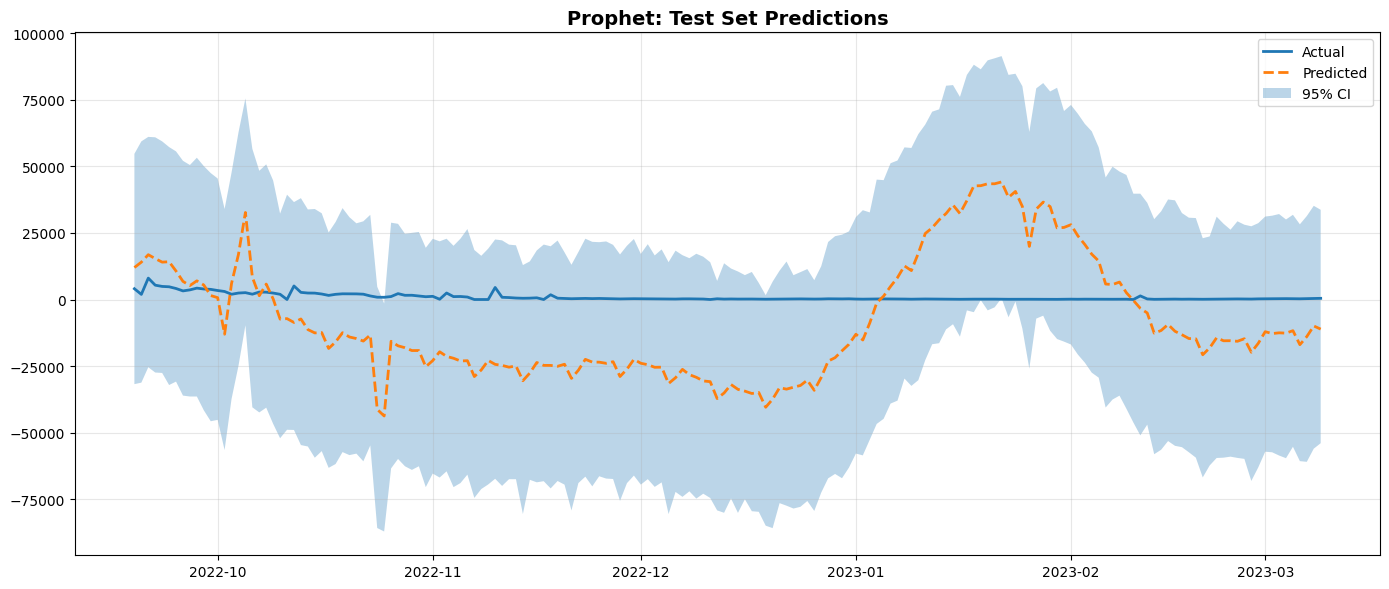

In [5]:
if prophet_available:
    # In-sample predictions on test set
    test_predictions = model.predict_in_sample(test_df)
    
    # Extract predictions
    y_test = test_df['new_cases'].values
    y_pred = test_predictions['yhat'].values
    
    # Evaluate
    print("Test Set Performance:")
    metrics = MetricsCalculator.print_metrics(y_test, y_pred, prefix="Test ")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(test_df['date'], y_test, label='Actual', linewidth=2)
    ax.plot(test_df['date'], y_pred, label='Predicted', linewidth=2, linestyle='--')
    ax.fill_between(test_df['date'], 
                    test_predictions['yhat_lower'], 
                    test_predictions['yhat_upper'],
                    alpha=0.3, label='95% CI')
    ax.set_title('Prophet: Test Set Predictions', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/04_prophet_predictions.png', dpi=300)
    plt.show()
else:
    # Simple baseline using 7-day moving average
    y_test = test_df['new_cases'].values
    y_pred = test_df['new_cases'].shift(1).rolling(window=7).mean().fillna(method='ffill').values
    
    print("Baseline (7-day MA) Performance:")
    metrics = MetricsCalculator.print_metrics(y_test, y_pred, prefix="Test ")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(test_df['date'], y_test, label='Actual', linewidth=2)
    ax.plot(test_df['date'], y_pred, label='7-day MA Baseline', linewidth=2, linestyle='--', color='orange')
    ax.set_title('Baseline: Test Set Predictions', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

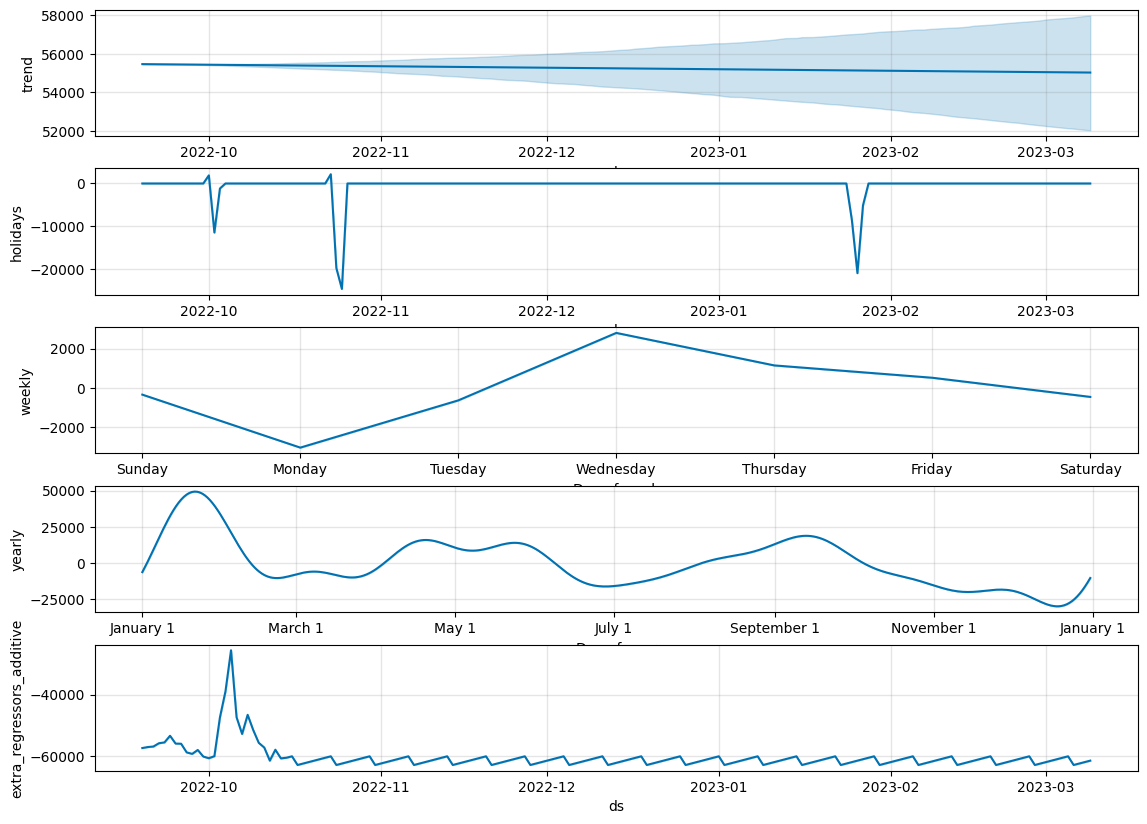


✓ Model saved to models/prophet_model.pkl


In [6]:
if prophet_available:
    # Component plots
    fig_components = model.model.plot_components(test_predictions)
    fig_components.set_size_inches(12, 8)
    plt.savefig('../reports/figures/04_prophet_components.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save model
    model.save('../models/prophet_model.pkl')
    print("\n✓ Model saved to models/prophet_model.pkl")
else:
    print("\n✓ Baseline model completed (no Prophet components available)")